In [77]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import open3d as o3d
from scipy.spatial.transform import Rotation as R 
import os 
import glob 
import pandas as pd 

Thông số camera

In [78]:
color_intrinsics = {
    'width': 1280,
    'height': 720,
    'fx': 643.90087890625,
    'fy': 643.1365356445312,
    'cx': 650.2113037109375,
    'cy': 355.79559326171875,
    'model': "distortion.inverse_brown_conrady",
    'coeffs': [-0.05658450722694397, 0.06544225662946701,-0.0008694113348610699, 0.00016751799557823688,-0.020957745611667633]
}

depth_intrinsics = {
    'width': 1280,
    'height': 720,
    'fx': 650.0616455078125,
    'fy': 650.0616455078125,
    'cx': 649.5928955078125,
    'cy': 360.9415588378906,
    'model': "distortion.brown_conrady",
    'coeffs': [0.0, 0.0, 0.0, 0.0, 0.0]
}

R_depth_to_color = np.array([

    [0.9999898076057434,    -0.00020347206736914814, -0.004507721401751041],
    [0.00018898719281423837, 0.9999948143959045,     -0.0032135415822267532],
    [0.004508351907134056,   0.003212657058611512,    0.9999846816062927]

    ])
t_depth_to_color = np.array([

    [-0.05905],
    [8.67399e-5],
    [0.00041]
    
    ])

In [95]:
def get_yolo_results_for_image(image_name, yolo_txt_dir):
    """
    Đọc file .txt kết quả YOLO tùy chỉnh và trích xuất bbox.
    Định dạng file dự kiến: {classname} {conf} {xmin} {xmax} {ymin} {ymax} ...
    
    Args:
        image_name (str): Tên file ảnh (ví dụ: "0000.png")
        yolo_txt_dir (str): Đường dẫn tới thư mục chứa file .txt
        
    Returns:
        list: Danh sách các bbox [[x_min, y_min, x_max, y_max], ...]
    """
    
    # 1. Tạo đường dẫn file .txt từ tên file ảnh
    base_name = os.path.splitext(image_name)[0]
    txt_name = base_name + ".txt"
    txt_path = os.path.join(yolo_txt_dir, txt_name)
    
    bboxes = []
    
    # 2. Kiểm tra file .txt có tồn tại không
    if not os.path.exists(txt_path):
        return []

    # 3. Đọc và xử lý file
    try:
        with open(txt_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                # 4. Parse 
                # {classname} {conf} {xmin} {xmax} {ymin} {ymax} ...
                parts = line.split()
                
                # Cần ít nhất 6 phần tử (class, conf, xmin, xmax, ymin, ymax)
                if len(parts) < 6:
                    print(f"  -> Cảnh báo: Dòng không hợp lệ trong {txt_name}: {line}")
                    continue
                    
                # 5. Trích xuất tọa độ pixel trực tiếp
                try:
                    x_min = int(float(parts[2]))
                    x_max = int(float(parts[3]))
                    y_min = int(float(parts[4]))
                    y_max = int(float(parts[5]))
                
                    # 6. Thêm vào list
                    bboxes.append([x_min, y_min, x_max, y_max])
                    
                except ValueError:
                    print(f"  -> Cảnh báo: Không thể parse tọa độ trong {txt_name}: {line}")

    except Exception as e:
        print(f"  -> Lỗi khi đọc file YOLO {txt_path}: {e}")
        return []
        
    return bboxes

In [ ]:
from scipy.ndimage import median_filter

def depth_to_pointcloud(depth_img, depth_intr, u, v):
    """
    Chuyển depth image sang point cloud 3D trong hệ depth.
    
    Args:
        depth_img: (H,W) ảnh depth (mm)
        depth_intr: dict {'fx','fy','cx','cy'}
        fill_holes: nếu True, điền lỗ nhỏ bằng median filter
    
    Returns:
        points_valid: (N,3) point cloud trong hệ depth
    """
    h, w = depth_img.shape
    u, v = np.meshgrid(np.arange(w, dtype=np.float32),
                       np.arange(h, dtype=np.float32))
    
    Z = depth_img.astype(np.float32) / 1000.0  # mm → m
    valid = (Z > 0.01) & (Z < 5.0) & np.isfinite(Z)
    
    if fill_holes:
        Z_filled = median_filter(Z, size=3)
        # Chỉ fill lỗ liền kề với điểm hợp lệ
        fill_mask = (~valid) & (cv2.dilate(valid.astype(np.uint8), np.ones((3,3), np.uint8)) > 0)
        Z[fill_mask] = Z_filled[fill_mask]
        valid = (Z > 0.01) & (Z < 5.0) & np.isfinite(Z)
    
    X = (u - depth_intr['cx']) * Z / depth_intr['fx']
    Y = (v - depth_intr['cy']) * Z / depth_intr['fy']
    
    points = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
    points_valid = points[valid.reshape(-1)]
    
    return points_valid

In [126]:
def get_point_cloud_in_box(points_3d, colors_intr, box_2d):
    """
    Lọc điểm trong bounding box 2D
    Args:
        points_3d: (N,3) điểm trong hệ color
        colors: (N,3) màu RGB [0-1]
        box_2d: (x_min, y_min, x_max, y_max) trong ảnh màu
    Returns:
        points_in_box: (M,3) điểm trong box
        colors_in_box: (M,3) màu tương ứng
    """
    x_min, y_min, x_max, y_max = box_2d
    
    # Chiếu ngược điểm 3D về ảnh màu
    H, W = 720, 1280
    
    # Chiếu điểm về pixel
    X, Y, Z = points_3d[:, 0], points_3d[:, 1], points_3d[:, 2]
    u = X * colors_intr['fx'] / Z + colors_intr['cx'] 
    v = Y * colors_intr['fy'] / Z + colors_intr['cy']
    
    # Lọc điểm trong box
    in_box = (u >= x_min) & (u < x_max) & (v >= y_min) & (v < y_max)
    points_in_box = points_3d[in_box]
    
    return points_in_box

In [127]:
def balanced_top_surface_centroid(points, top_percent=0.1, eps=1e-8):
    if points.shape[0]==0:
        return np.array([np.nan,np.nan,np.nan])

    # 1. Axis balancing cho X/Y
    std = np.std(points[:,:2], axis=0)
    scale = np.where(std<eps,1.0,std)
    whitened_xy = points[:,:2]/scale
    centroid_xy = np.mean(whitened_xy, axis=0) * scale

    # 2. Chọn top-surface Z
    z_vals = points[:,2]
    top_k = max(1,int(len(z_vals)*top_percent))
    top_idx = np.argsort(z_vals)[:top_k]
    top_points = points[top_idx]
    centroid_z = np.median(top_points[:,2])

    centroid = np.array([centroid_xy[0], centroid_xy[1], centroid_z])
    return centroid


In [128]:
# 1. TẠO DANH SÁCH ẢNH CẦN XỬ LÝ
base_path = r"D:\HaAnh\AI_race\train"
rgb_files = sorted(glob.glob(os.path.join(base_path, "rgb", "*.png")))
depth_files = sorted(glob.glob(os.path.join(base_path, "depth", "*.png")))

YOLO_TXT_DIR = r"D:\HaAnh\AI_race\yolo_result"

# 2. LIST ĐỂ LƯU KẾT QUẢ CUỐI CÙNG
all_final_outputs = []

# 3. VÒNG LẶP BÊN NGOÀI
for rgb_path, depth_path in zip(rgb_files, depth_files):
    
    IMAGE_FILENAME = os.path.basename(rgb_path)
    print(f"\n=================================================")
    print(f"ĐANG XỬ LÝ ẢNH: {IMAGE_FILENAME}")
    print(f"=================================================")

    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
    img = cv2.imread(rgb_path, cv2.IMREAD_UNCHANGED)
    
    if depth is None or img is None:
        print(f"  -> Lỗi: Không load được ảnh {IMAGE_FILENAME}")
        continue
        
    all_yolo_bboxes = get_yolo_results_for_image(
        IMAGE_FILENAME, 
        YOLO_TXT_DIR
    )
    
    if not all_yolo_bboxes:
        print("  -> Không tìm thấy bounding box nào.")
        all_final_outputs.append((IMAGE_FILENAME, None, None, None))
        continue
        
    print(f"Bắt đầu Trích xuất 3D points cho {len(all_yolo_bboxes)} ứng cử viên...")

    candidate_parcels_info = []
    for i, bbox in enumerate(all_yolo_bboxes):
        try:
            # points_3d, colors_3d = get_point_cloud_from_bbox(
            #     bbox, depth, img, 
            #     depth_intrinsics, color_intrinsics, 
            #     R_depth_to_color, t_depth_to_color
            # )

            # points_full, colors_full = map_depth_to_color_3d(depth, img, depth_intrinsics, color_intrinsics,
            #                                     R_depth_to_color, t_depth_to_color)
            
            # points_3d, colors_3d = get_point_cloud_in_box(points_full, colors_full, bbox)

            points_full = depth_to_pointcloud(depth, depth_intrinsics, fill_holes=True)
            points_3d = get_point_cloud_in_box(points_full, color_intrinsics, bbox)

            if len(points_3d) > 0:
                candidate_parcels_info.append({
                    'points_3d': points_3d,

                    'original_bbox': bbox
                })
        except Exception as e:
            print(f"  -> Lỗi khi xử lý bbox {bbox}: {e}")

    #final_candidates = candidate_parcels_info
    #--- BƯỚC 4: TÍNH TÂM 3D ---
    print("\nBắt đầu Tính toán Tâm 3D (lọc outlier + trung bình có trọng số)...")
    final_candidates = []

    for i, parcel_info in enumerate(candidate_parcels_info):
        parcel_points_3d = parcel_info['points_3d']
        if len(parcel_points_3d) < 100:
            print(f"  -> Bỏ qua ứng cử viên {i}: quá ít điểm.")
            continue

        #--- Lọc nhiễu không gian ---
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(parcel_points_3d)
        pcd_clean, ind = pcd.remove_statistical_outlier(nb_neighbors=30, std_ratio=1.0)
        filtered_points = np.asarray(pcd_clean.points)

        # --- Trung bình có trọng số ---
        mean = np.mean(filtered_points, axis=0)
        dist = np.linalg.norm(filtered_points - mean, axis=1)
        # mask = dist < np.percentile(dist, 80)
        q1, q3 = np.percentile(dist, [25, 75])
        iqr = q3 - q1
        mask = dist < (q3 + 1.5 * iqr)

        stable_points = filtered_points[mask]

        #center_3d = np.median(stable_points, axis=0)
        center_3d = balanced_top_surface_centroid(stable_points)

        final_candidates.append({
            'center_3d': center_3d,
            'original_info': parcel_info
        })

        print(f"  Ứng cử viên {i}: Tâm 3D (sau lọc) = ({center_3d[0]:.3f}, {center_3d[1]:.3f}, {center_3d[2]:.3f})")

    # --- BƯỚC 5: CHỌN BƯU KIỆN CUỐI CÙNG ---
    print("\nBắt đầu Chọn bưu kiện cuối cùng...")
    top_parcel = None
    num_candidates = len(final_candidates)
    
    if num_candidates == 0:
        print("[KẾT QUẢ]: Không có ứng cử viên hợp lệ.")
        all_final_outputs.append((IMAGE_FILENAME, None, None, None)) # Chỉ 3 cột x,y,z
        continue # Thêm continue ở đây
        
    elif num_candidates == 1:
        top_parcel = final_candidates[0]
        print(f"[KẾT QUẢ]: Chọn ứng cử viên duy nhất.")
    else:
        print(f"Phát hiện {num_candidates} ứng cử viên. Áp dụng luật Tie-Break...")
        
        # ==================================================================
        # === SỬA LOGIC: "TRÊN CÙNG" = Z NHỎ NHẤT ===
        # ==================================================================
        
        # Sắp xếp theo Z TĂNG DẦN (reverse=False) để tìm vật GẦN NHẤT
        final_candidates.sort(key=lambda c: c['center_3d'][2], reverse=False) 
        
        # Đây là Z của vật gần nhất
        z_min = final_candidates[0]['center_3d'][2] 
        
        # Nhóm các bưu kiện có chênh lệch độ cao < 5mm
        # So sánh với z_min, không phải z_max
        tie_group = [c for c in final_candidates if abs(c['center_3d'][2] - z_min) < 0.005]
        print(f"  -> {len(tie_group)} bưu kiện có cùng độ cao GẦN NHẤT (±5mm).")
        # ==================================================================
        
        if len(tie_group) == 1:
            top_parcel = tie_group[0]
        else:
            # Ưu tiên bưu kiện xa robot nhất (|Y| lớn nhất)
            # Ràng buộc này trong đề bài là đúng, code bạn đã làm đúng
            tie_group.sort(key=lambda c: abs(c['center_3d'][1]), reverse=True)
            top_parcel = tie_group[0]
            print(f"  -> Chọn vật xa robot nhất (|Y| lớn nhất).")

    if top_parcel is not None:
        c = top_parcel['center_3d']
        print(f"\n--- [KẾT QUẢ CUỐI CÙNG CHO ẢNH {IMAGE_FILENAME}] ---")
        print(f"  Tâm gắp (x, y, z): ({c[0]:.4f}, {c[1]:.4f}, {c[2]:.4f})")
        # Chỉ lưu 3 cột x,y,z
        all_final_outputs.append((IMAGE_FILENAME, c[0], c[1], c[2]))
    else:
        print(f"\n[KẾT QUẢ]: Không chọn được bưu kiện nào.")
        # Chỉ lưu 3 cột x,y,z
        all_final_outputs.append((IMAGE_FILENAME, None, None, None))

print("\n=== HOÀN TẤT QUÁ TRÌNH ===")


ĐANG XỬ LÝ ẢNH: 0000.png
Bắt đầu Trích xuất 3D points cho 1 ứng cử viên...

Bắt đầu Tính toán Tâm 3D (lọc outlier + trung bình có trọng số)...
  Ứng cử viên 0: Tâm 3D (sau lọc) = (-0.058, 0.041, 1.056)

Bắt đầu Chọn bưu kiện cuối cùng...
[KẾT QUẢ]: Chọn ứng cử viên duy nhất.

--- [KẾT QUẢ CUỐI CÙNG CHO ẢNH 0000.png] ---
  Tâm gắp (x, y, z): (-0.0584, 0.0408, 1.0560)

ĐANG XỬ LÝ ẢNH: 0001.png
Bắt đầu Trích xuất 3D points cho 2 ứng cử viên...

Bắt đầu Tính toán Tâm 3D (lọc outlier + trung bình có trọng số)...
  Ứng cử viên 0: Tâm 3D (sau lọc) = (-0.082, -0.162, 1.082)
  Ứng cử viên 1: Tâm 3D (sau lọc) = (-0.057, 0.041, 1.058)

Bắt đầu Chọn bưu kiện cuối cùng...
Phát hiện 2 ứng cử viên. Áp dụng luật Tie-Break...
  -> 1 bưu kiện có cùng độ cao GẦN NHẤT (±5mm).

--- [KẾT QUẢ CUỐI CÙNG CHO ẢNH 0001.png] ---
  Tâm gắp (x, y, z): (-0.0575, 0.0408, 1.0580)

ĐANG XỬ LÝ ẢNH: 0002.png
Bắt đầu Trích xuất 3D points cho 2 ứng cử viên...

Bắt đầu Tính toán Tâm 3D (lọc outlier + trung bình có trọng số

In [129]:
df = pd.DataFrame(all_final_outputs, 
                  columns=['image_filename', 'x', 'y', 'z'])

output_csv_path = "submission7.csv"
df.to_csv(output_csv_path, index=False, float_format='%.6f')

print(f"Đã lưu kết quả ra file: {output_csv_path}")
df.head()


Đã lưu kết quả ra file: submission7.csv


,image_filename,x,y,z
0,0000.png,-0.058408,0.040765,1.056
1,0001.png,-0.057458,0.040785,1.058
2,0002.png,-0.097932,-0.145982,1.021
3,0003.png,-0.113919,-0.190170,0.931
4,0004.png,0.122755,-0.204269,0.999


In [130]:
gt = pd.read_csv(r"D:\HaAnh\AI_race\public_train.csv")
pred = pd.read_csv(r"D:\HaAnh\AI_race\submission7.csv")

# chuẩn hoá tên trước khi merge:
pred['image_filename'] = pred['image_filename'].apply(
    lambda x: x if x.startswith('image_') else f"image_{x}"
)

merged = pd.merge(gt, pred, on='image_filename', suffixes=('_gt', '_pred'))

merged['err'] = np.sqrt(
    (merged['x_gt'] - merged['x_pred'])**2 +
    (merged['y_gt'] - merged['y_pred'])**2 +
    (merged['z_gt'] - merged['z_pred'])**2
)

merged['MCE_i'] = np.minimum(merged['err'] / 0.05, 1.0)

MCE = merged['MCE_i'].mean()

print(f"Mean Center Error (MCE): {MCE:.4f}")
print(f"→ Điểm tương ứng: {(1 - MCE)*100:.2f}%")

print("\nThống kê thêm:")
print(f"  Trung vị sai số: {merged['err'].median()*1000:.2f} mm")
print(f"  Trung bình sai số: {merged['err'].mean()*1000:.2f} mm")
print(f"  % ảnh hợp lệ (err ≤ 5cm): {(merged['err'] <= 0.05).mean()*100:.2f}%")


Mean Center Error (MCE): 0.4154
→ Điểm tương ứng: 58.46%

Thống kê thêm:
  Trung vị sai số: 14.18 mm
  Trung bình sai số: 31.61 mm
  % ảnh hợp lệ (err ≤ 5cm): 87.33%


Saved per-image MCE to: per_image_mce.csv

Per-image MCE summary:
        count       mean        std       min       25%        50%        75%  \
err_mm  150.0  31.612807  51.666533  1.199677  7.216542  14.180593  34.972191   
MCE_i   150.0   0.415413   0.326229  0.023994  0.144331   0.283612   0.699444   

               max  
err_mm  331.091243  
MCE_i     1.000000  

Top 10 worst images (by Euclidean error):
image_filename     err_mm  MCE_i
image_0016.png 331.091243    1.0
image_0136.png 263.826234    1.0
image_0102.png 256.737502    1.0
image_0093.png 216.223614    1.0
image_0107.png 213.755162    1.0
image_0090.png 189.338965    1.0
image_0137.png 173.376663    1.0
image_0041.png 142.335638    1.0
image_0051.png 136.420961    1.0
image_0084.png 129.006539    1.0

Top 10 best images (by Euclidean error):
image_filename   err_mm    MCE_i
image_0040.png 1.199677 0.023994
image_0035.png 1.607800 0.032156
image_0129.png 2.159510 0.043190
image_0026.png 2.585090 0.051702
image_0001.png

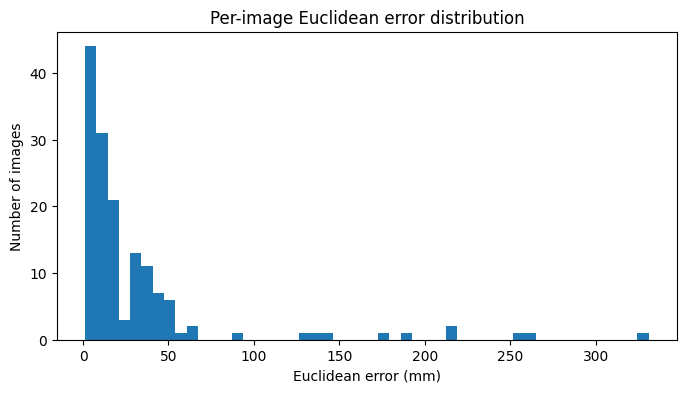


Pass rate (err ≤ 5cm): 87.33%


In [86]:
# Compute per-image MCE and save results
# Assumes `merged` dataframe exists from previous cell
per_file = merged.copy()
per_file['err_mm'] = per_file['err'] * 1000.0
per_file['MCE_i'] = np.minimum(per_file['err'] / 0.05, 1.0)

# Select and order columns for output
out_cols = ['image_filename', 'x_gt', 'y_gt', 'z_gt', 'x_pred', 'y_pred', 'z_pred', 'err', 'err_mm', 'MCE_i']
per_file_out = per_file[out_cols]

# Save CSV
out_path = 'per_image_mce.csv'
per_file_out.to_csv(out_path, index=False, float_format='%.6f')
print(f"Saved per-image MCE to: {out_path}")

# Print summary statistics
print('\nPer-image MCE summary:')
print(per_file_out[['err_mm','MCE_i']].describe().T)

# Top 10 worst images by error
topk = per_file_out.sort_values('err', ascending=False).head(10)
print('\nTop 10 worst images (by Euclidean error):')
print(topk[['image_filename','err_mm','MCE_i']].to_string(index=False))

# Top 10 best images
bestk = per_file_out.sort_values('err', ascending=True).head(10)
print('\nTop 10 best images (by Euclidean error):')
print(bestk[['image_filename','err_mm','MCE_i']].to_string(index=False))

# Histogram of errors
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(per_file_out['err_mm'].dropna(), bins=50)
plt.xlabel('Euclidean error (mm)')
plt.ylabel('Number of images')
plt.title('Per-image Euclidean error distribution')
plt.show()

# Optional: compute per-file pass rate at 5cm
pass_rate = (per_file_out['err'] <= 0.05).mean()
print(f"\nPass rate (err ≤ 5cm): {pass_rate*100:.2f}%")

Found 19 images with MCE ==1 (threshold 0.999999).
image_filename     err_mm  MCE_i
image_0008.png  50.088429    1.0
image_0011.png  50.040272    1.0
image_0016.png 331.091243    1.0
image_0033.png  61.959631    1.0
image_0041.png 142.335638    1.0
image_0049.png  50.720086    1.0
image_0051.png 136.420961    1.0
image_0065.png  65.172525    1.0
image_0073.png  55.278648    1.0
image_0084.png 129.006539    1.0
image_0090.png 189.338965    1.0
image_0093.png 216.223614    1.0
image_0099.png  51.262632    1.0
image_0102.png 256.737502    1.0
image_0107.png 213.755162    1.0
image_0112.png  88.240763    1.0
image_0113.png  51.449474    1.0
image_0136.png 263.826234    1.0
image_0137.png 173.376663    1.0
Saved list to mce_eq_1_list.txt
Copied 19 images to mce_eq_1_examples. 0 not found.


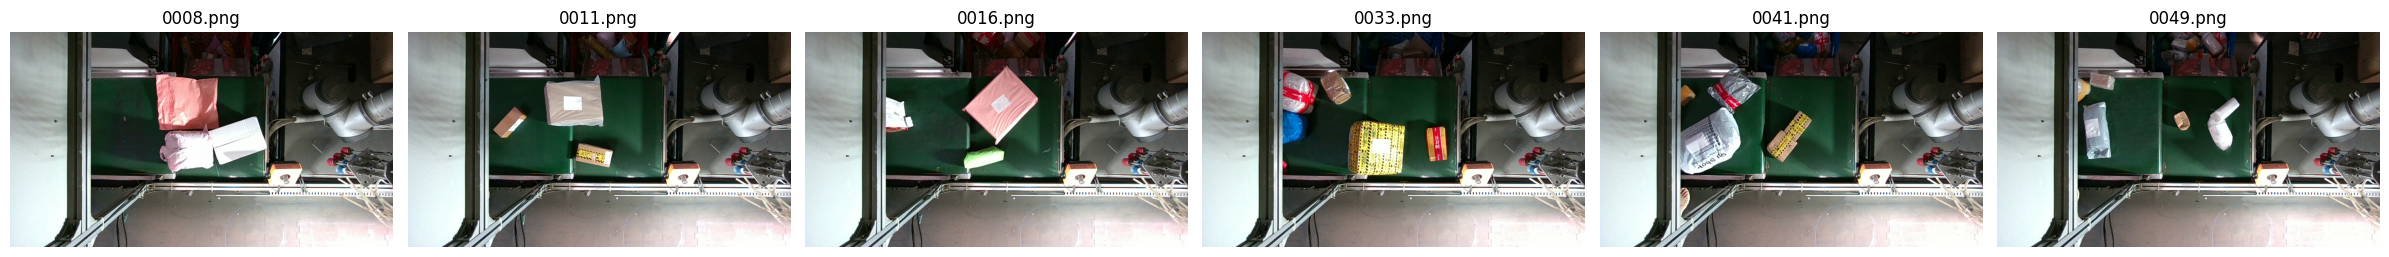

In [87]:
# Export and preview images with MCE == 1
mce_threshold = 0.999999
mce1 = per_file_out[per_file_out['MCE_i'] >= mce_threshold].copy()

print(f"Found {len(mce1)} images with MCE ==1 (threshold {mce_threshold}).")
if len(mce1) == 0:
    print('No images meet the threshold.')
else:
    # Print filenames and errors
    print(mce1[['image_filename','err_mm','MCE_i']].to_string(index=False))

    # Save list
    list_path = 'mce_eq_1_list.txt'
    mce1['image_filename'].to_csv(list_path, index=False, header=False)
    print(f"Saved list to {list_path}")

    # Copy RGB images to a folder for quick inspection
    import shutil
    out_dir = 'mce_eq_1_examples'
    os.makedirs(out_dir, exist_ok=True)

    # Determine rgb dir (try known variables)
    if 'base_path' in globals():
        rgb_dir = os.path.join(base_path, 'rgb')
    else:
        # fallback to repo-relative path
        rgb_dir = os.path.join('train', 'rgb')

    not_found = []
    copied = []
    for fn in mce1['image_filename']:
        candidates = [fn, fn.replace('image_', ''), fn.replace('image_','').lstrip('0')]
        src = None
        for cand in candidates:
            cand_path = os.path.join(rgb_dir, cand)
            if os.path.exists(cand_path):
                src = cand_path
                break
        if src is None:
            not_found.append(fn)
            continue
        dst = os.path.join(out_dir, os.path.basename(cand))
        try:
            shutil.copy(src, dst)
            copied.append(dst)
        except Exception as e:
            print(f"Failed to copy {src} -> {dst}: {e}")

    print(f"Copied {len(copied)} images to {out_dir}. {len(not_found)} not found.")
    if len(not_found) > 0:
        print('Not found samples (first 10):', not_found[:10])

    # Preview up to 6 images inline
    import matplotlib.pyplot as plt
    preview = copied[:6]
    if len(preview) > 0:
        n = len(preview)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
        if n == 1:
            axes = [axes]
        for ax, p in zip(axes, preview):
            img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
            if img is None:
                ax.set_title(f'{os.path.basename(p)}\n(not loaded)')
                ax.axis('off')
                continue
            # convert BGR->RGB if needed
            if img.ndim == 3 and img.shape[2] == 3:
                img_rgb = img[:, :, ::-1]
            else:
                img_rgb = img
            ax.imshow(img_rgb)
            ax.set_title(os.path.basename(p))
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print('No copied images to preview.')
